Below we will define several functions to do the tasks:

First we define the function *generate_patterns*. The parameters are P and N;
which are the number of patterns and the size of them, and also the number of neurons. It returns a matrix of P columns and N rows with random values $\in$ {-1,1}.

We define a function *generate_Weight*. We create a weight matrix using the patterns created with the function *generate_patterns*. It is computed as  
$ J_{ij} = \frac{1}{N} \sum_{\mu=1}^{P} x_{i}^{(\mu)} x_{j}^{(\mu)}. $

We define a function *initial_condition*. It returns an N-dimensional array with random entries $\in$ {-1,1}.

We also define a *function network_dinamics_asyncr1*. The parameters are the time steps, the Weight matrix and the initial condition. It simulates the dinamic of the Hopfield model for a given $σ_{0}$, Weight matrix and time steps.

We define a *random_vector* function. The parameters are *n* and *k*. It creates an *n*-dimensional vector with *k* 1's and *n-k* zeros, but with random positions. It also considers the case in which *k* is not an integer.

We define a *change_bits* function. The parameters are *ratio, N, X and column*.
We change *ratio* *N randomly bits from a selected column of the matrix X. We use the function *random_vector*.

We define *correctness* function. Given two patterns and a treshold, we compute the hamming distance $d_H(x_{i}^\mu, x_{i}^\nu)
= \frac{1}{2} \sum_{i=1}^N \left| x_{i}^\mu - x_{i}^\nu \right|
$
 and the overlap $
m(x_{i}^\mu, x_{i}^\nu)
= \frac{1}{N} \sum_{i=1}^N x_{i}^\mu \, x_{i}^\nu
$. Then, we decide if the pattern is succesfully stored depending in two criterias (one with Hamming distance and the other considering the overlap).

We also define the *measuring_recall1* function. The parameters are a matrix of weights *M*, the *ratio*, *time_steps*, a matrix of patterns*X*, *column* and *treshold*. First, it computes the bits that are changed due to the *ratio*. Then, we reproduce the dynamics of the Hopfield model. Finally, it returns the overlap and True/False depending on the treshold.

We define the *measuring_capacity1* function. Given an array of integers P (the different numbers of patterns that we will consider), *N*, *time_steps*, *treshold*, *ratio*, and *number_experiments*; it returns a vector with the different performances for each of the P's in *P_values*.





In [ ]:
import numpy as np
from scipy.spatial import distance

def generate_patterns(num_patterns,num_neurons):
    """
    Generate a matrix of random patterns (-1 or 1) to store in the Hopfield network.

    Args:
        num_patterns (int): Number of patterns P
        num_neurons (int): Number of neurons N

    Returns:
        np.ndarray: Shape (num_neurons, num_patterns)
    """
    return np.random.choice([1,-1], size = (num_neurons,num_patterns))

def generate_Weight(patterns):
    """
    Compute the Hopfield weight matrix using the Hebbian learning rule.

    Args:
        patterns (np.ndarray): Matrix of patterns, shape (num_neurons, num_patterns)

    Returns:
        np.ndarray: Weight matrix, shape (num_neurons, num_neurons)
    """
    num_neurons = patterns.shape[0]
    Weights = (patterns@patterns.T)/num_neurons #Faster multiplication(Python, in C++ for example, not)
    #slower alternative
    #M = np.zeros((N,N))
    #for i in range(N):
     # for j in range(N):
      #  M[i][j] = (1/N)*(X[i,:]@X[j,:])
    np.fill_diagonal(Weights,0)
    #as we ignore the diagonal values, we could fill the diagonal as zero
    #no self-inputs
    return Weights

def initial_state(num_neurons):
    """
    Generate a random initial state for the network.

    Args:
        num_neurons (int): Number of neurons N

    Returns:
        np.ndarray: Random state vector (-1 or 1)
    """
    return np.random.choice([-1,1],size =num_neurons)

def network_dinamics_asyncr1(time_steps, weight_matrix, initial_state):
    """
      Simulate the asynchronous Hopfield network dynamics.

      Args:
          num_steps (int): Number of update steps
          weight_matrix (np.ndarray): Weight matrix W
          initial_state (np.ndarray): Initial neuron states sigma_0

      Returns:
          np.ndarray: Final state after dynamics
    """
    state = initial_state.copy()
    for t in range(time_steps):
      i = np.random.randint(len(state))
      operation = weight_matrix[i, :]@state
      #slower computation
      #op -= M[i,i]*sigma[i]
      #and then we extract the self-input, but self-input is 0
      #for j in range(len(sigma)):
      # op+=M[i][j]*sigma[j]
      state[i] = 1 if operation >=0 else -1
    return state

def random_vector(length,num_ones):
  """
    Create a random binary vector with a specified number of 1s.

    Args:
        length (int): Total vector length
        num_ones (float): Number of ones (can be non-integer)

    Returns:
        np.ndarray: Random vector with 1s and 0s
  """
  int_part = int(np.floor(num_ones))
  frac_part = num_ones-int_part

  final_ones = int_part + (np.random.rand() < frac_part)

  vec = np.array([1]*final_ones + [0]*(length-final_ones))
  np.random.shuffle(vec)

  return vec

def change_bits(ratio_change, num_neurons, pattern_matrix, pattern_index):
  """
    Flip a fraction of bits in a given pattern.

    Args:
        ratio_change (float): Fraction of bits to flip
        num_neurons (int): Number of neurons
        pattern_matrix (np.ndarray): Original patterns (num_neurons x num_patterns)
        pattern_index (int): 1-based index of pattern to modify

    Returns:
        np.ndarray: Modified pattern
  """
  number_change = ratio_change*num_neurons
  #here ratio represents the number of bits that you want to change from the original pattern
  flips = random_vector(num_neurons, number_change)
  pattern_matrix_modified = pattern_matrix.copy()
  for i in range (num_neurons):
    if flips[i] == 1:
      pattern_matrix_modified[i,pattern_index-1] = 1 if pattern_matrix[i,pattern_index-1] == -1 else -1
  return pattern_matrix_modified[:,pattern_index-1]

def correctness(pattern_original, pattern_retrieved, treshold):
  """
    Evaluate whether a pattern was successfully recalled.

    Args:
        pattern_original (np.ndarray): Original stored pattern
        pattern_retrieved (np.ndarray): Retrieved pattern after dynamics
        threshold (float): Threshold to consider recall successful

    Returns:
        Several prints of the correctness of the dynamics
  """
  d = distance.hamming(pattern_original,pattern_retrieved)
  if(1-d >= treshold):
    print('succesfully stored with hamming distance criteria: ', 1-d)
  if(1-d <treshold):
    print('not succesfully stored with hamming distance criteria:', 1-d)
  overlap = (pattern_original@pattern_retrieved)/len(pattern_original)
  if(overlap>= treshold):
    print('succesfully stored with overlap criteria: ', overlap)
  if(overlap<treshold):
    print('not succesfully stored with overlap criteria:', overlap)

def measuring_recall1(weight_matrix, ratio_change, time_steps, pattern_matrix, pattern_index, treshold):
    """
      Measure recall performance for a single pattern.

      Args:
          weight_matrix (np.ndarray): Weight matrix
          pattern_matrix (np.ndarray): Stored patterns
          pattern_index (int): 1-based index of pattern to test
          ratio_change (float): Fraction of bits to flip in initial state
          time_steps (int): Number of asynchronous updates
          threshold (float): Overlap threshold for success

      Returns:
          tuple: (success, overlap)
    """
    changed = change_bits(ratio_change, len(weight_matrix[:,0]),pattern_matrix, pattern_index)
    actual_state = network_dinamics_asyncr1(time_steps, weight_matrix, changed)
    overlap = (actual_state@pattern_matrix[:,pattern_index-1])/len(actual_state)
    return overlap >= treshold, overlap

def measuring_capacity1(P_vector,num_neurons,time_steps, treshold, change_ratio, number_experiments):
  """
    Evaluate performance of Hopfield network for different numbers of patterns.

    Args:
        P_vector (list[int]): Different numbers of patterns to test
        num_neurons (int): Number of neurons in network
        time_steps (int): Number of time steps per recall
        threshold (float): Success threshold for recall
        change_ratio (float): Fraction of bits to flip initially
        num_experiments (int): Number of experiments per pattern count

    Returns:
        list[float]: Performance for each pattern count
  """
  performances = []
  for P in P_vector:
    success_pattern_count = 0
    for experiment in range(number_experiments):
        # Generate patterns and create weight matrix
        X = generate_patterns(P, num_neurons)
        M = generate_Weight(X)

        # Test recall for each pattern
        for i in range(P):
            success_pattern= measuring_recall1(M,change_ratio, time_steps, X, i+1, treshold)[0]
            if success_pattern:
                success_pattern_count += 1
    performance = success_pattern_count / (number_experiments*P)
    performances.append(performance)
    print(f"P={P}, α={P/num_neurons:.8f}, Performance={performance:.8f}")
  return performances



Hopfield Simulation Code
1. Generate patterns $x
^{(1)}$, . . . , $x^{(P)}$
for the network to store.
2. Create the weight matrix J.
3. For a given initial condition $σ_{0}$ and number of time steps, simulate
the network dynamics according to the rule (1).

We initialize with a number P = 20 of patterns of size N = 200 (also the number of neurons), we also consider time_steps = 600. Then, we generate the patterns, the Weight Matrix, an initial condition $σ_{0}$, and we simulate the Hopfield network dynamics according to the rule(1).  

In [ ]:
P = 20
N = 200
time_steps = 600
X = generate_patterns(P,N)
M = generate_Weight(X)
sigma_zero = initial_state(N)
#print('sigma_zero:',sigma_zero)
sigma_actual = network_dinamics_asyncr1(time_steps, M, sigma_zero)
#print('sigma_actualitzada:',sigma_actual)

Now we will try some criteria changing a ratio 0.1 of bits using the function that we have previously created for this purpose.
A practical criterion is to measure the overlap between the network state $σ(t)$ and the pattern selected $x^{(1)}$. The overlap is computed as $m(t) \;=\; \frac{1}{N} \sum_{i=1}^N \sigma_i(t)\, x_i^{(1)}
\quad , \quad \sigma_i(t), x_i^{(1)} \in \{-1, +1\}.$
Then we may say that the criteria is succesful if the overlap is bigger than a certain treshold. Recall is successful if $\exists\, t \leq T_{\max}
\;\; $such that $m(t) >= θ$. We have selected θ = 0.98, but it can be changed in the code.

Notice that apart from that criterion it could be interesting computing the Hamming distance (that was mentioned before), for that reason we have used it in the *correctness* function.



In [ ]:
#now in X1, we have X^1 with 'number_change' randomly changed bits
treshold = 0.95
ratio = 0.1
column = 1
X1 = change_bits(ratio, N, X, column)
sigma_actual1 = network_dinamics_asyncr1(time_steps,M,X1)
#print(sigma_actual1)
#print(X[:,0])
#print(X1[:,0])
correctness(sigma_actual1,X[:,0], treshold)

succesfully stored with hamming distance criteria:  0.995
succesfully stored with overlap criteria:  0.99


Now we will only compare with the inital patterns without changing its bits, so the *ratio* will be 0.
We will use the *measuring_recall* function for each pattern in X. Note that we will use X and M, the ones from the first computation.

In [ ]:
ratio = 0
count = 0
for i in range(P):
  a = measuring_recall1(M, ratio, time_steps, X, i+1, treshold)
  if a[0] == True:
    count += 1
print('ratio of succesful recalled patterns ',count/P)



ratio of succesful recalled patterns  1.0


Now we will measure the capacity for different values of P; we will use the treshold as 0.95. Note that for more precision, as it is a simulation of the network, you should increase the number of experiments.

In [ ]:
N = 400
P_values = [10,20,30,40,50,60,70,80,100,120,150,200,250,300]
ratio = 0
treshold = 0.95
time_steps = 600
number_experiments = 10
# Measure capacity
performances = measuring_capacity1(P_values, N, time_steps, treshold, ratio,number_experiments)


P=10, α=0.02500000, Performance=1.00000000
P=20, α=0.05000000, Performance=1.00000000
P=30, α=0.07500000, Performance=1.00000000
P=40, α=0.10000000, Performance=1.00000000
P=50, α=0.12500000, Performance=1.00000000
P=60, α=0.15000000, Performance=0.97666667
P=70, α=0.17500000, Performance=0.93285714
P=80, α=0.20000000, Performance=0.77000000
P=100, α=0.25000000, Performance=0.33800000
P=120, α=0.30000000, Performance=0.06166667
P=150, α=0.37500000, Performance=0.00133333
P=200, α=0.50000000, Performance=0.00000000
P=250, α=0.62500000, Performance=0.00000000
P=300, α=0.75000000, Performance=0.00000000


We will plot the performance as a function of α = P/N.

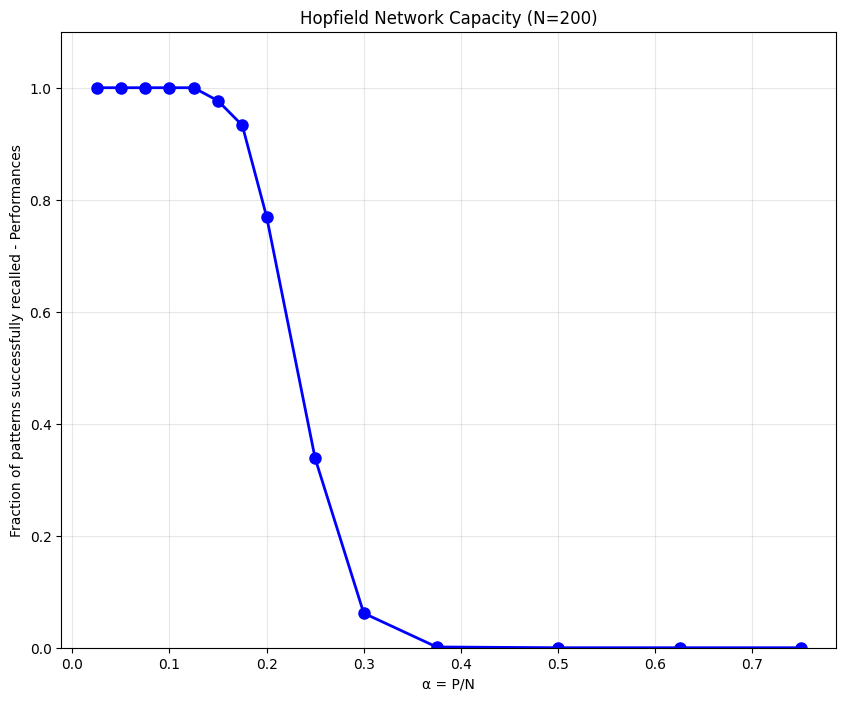

In [ ]:
import matplotlib.pyplot as plt
alphas = [P/N for P in P_values]

plt.figure(figsize = (10,8))
plt.plot(alphas, performances, 'bo-', linewidth=2, markersize=8)
plt.xlabel('α = P/N')
plt.ylabel('Fraction of patterns successfully recalled - Performances')
plt.title('Hopfield Network Capacity (N=200)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.show()

We also define a *function network_dinamics_asyncr2*. The parameters are the time steps, the Weight matrix and the initial condition. It simulates the dinamic of the Hopfield model for a given $σ_{0}$, Weight matrix and time steps. In this case, the function treats several patterns at once

We also define a *function network_dinamics_syncr1*. The parameters are the time steps, the Weight matrix and the initial condition. It simulates the dinamic of the Hopfield model for a given $σ_{0}$, Weight matrix and time steps. It acualizes synchronously (ie. all neurons are actualized at the same time for each time step). It can treat several patterns at once also

In [ ]:
def network_dinamics_asyncr2(time_steps, weight_matrix, initial_states):
  """
        Simulate asynchronous Hopfield dynamics for several patterns at once.
        Each pattern evolves independently, updating one random neuron per step.

        Args:
            time_steps (int): Number of iterations.
            weight_matrix (np.ndarray): Weight matrix (N x N).
            initial_states (np.ndarray): Initial states matrix (N x P),
                                         where P is number of independent patterns.

        Returns:
            np.ndarray: Final state matrix (N x P).
  """
  #in this case, it actualizes several patterns at once
  sigma = initial_states.copy()
  for t in range(time_steps):
    indices = np.random.randint(sigma.shape[0], size = sigma.shape[1])
    #we select B indices randomly from 1 to N
    for j in range(sigma.shape[1]):
      i = indices[j]
      op = weight_matrix[i, :]@sigma[:,j]
      #slower computation
      #op -= M[i,i]*sigma[i]
      #and then we extract the self-input, but self-input is 0
      #for j in range(len(sigma)):
      # op+=M[i][j]*sigma[j]
      sigma[i,j] = 1 if op >=0 else -1
  return sigma

def network_dinamics_syncr1(time_steps, weight_matrix, initial_state):
  """
        Simulate synchronous Hopfield dynamics.
        All neurons (for all patterns) are updated simultaneously at each time step.
        Also we can treat only one pattern.

        Args:
            time_steps (int): Number of iterations.
            weight_matrix (np.ndarray): Weight matrix (N x N).
            initial_states (np.ndarray): Initial states matrix (N x P),
                                         where P is number of independent patterns.

        Returns:
            np.ndarray: Final state matrix (N x P).
  """
  sigma = initial_state.copy()
  for t in range(time_steps):
    op = weight_matrix@sigma
    #slower computation
    #we could do op = M@auxiliar
    #op = np.where (op>=0, 1,-1)
    #this function actualizes each neuron depending on the condition
    sigma = np.where(op >=0,1,-1)
  return sigma

In first place, we will compare the speed of the synchronous and asynchronous simulation for only one pattern.

In [ ]:
import time
P = 200
N = 2000
time_steps = 1600
X = generate_patterns(P,N)
M = generate_Weight(X)
sigma_zero = initial_state(N)
start = time.time()
sigma_actual = network_dinamics_asyncr1(time_steps, M, sigma_zero)
print('Asynchronous Time: ', time.time()-start)
start = time.time()
sigma_acutal2 = network_dinamics_syncr1(time_steps, M, sigma_zero)
print('Synchronous Time: ', time.time()-start)

Asynchronous Time:  0.022478342056274414
Synchronous Time:  4.491424798965454


Now, we will compare the speed of the synchonous and asynchronous simulation for some patterns, for example 10 patterns.

In [ ]:
import time
P = 200
N = 2000
time_steps = 1600
X = generate_patterns(P,N)
M = generate_Weight(X)
#we select in p the number of patterns treated at once
p = 10
sigma_zero = np.random.choice([1,-1], size = (N,p))
start = time.time()
sigma_actual = network_dinamics_asyncr2(time_steps, M, sigma_zero)
print('Asynchronous Time: ', time.time()-start)
start = time.time()
sigma_acutal2 = network_dinamics_syncr1(time_steps, M, sigma_zero)
print('Synchronous Time: ', time.time()-start)

Asynchronous Time:  0.13481426239013672
Synchronous Time:  14.383387088775635


So we have seen that for treating only a pattern is much faster the asynchronous, and for treating multiple patterns also. It is observed that synchronous dinamics is approximately 2 times slower. It is understandable, as in each time step is treating more neurons.

Concretely, we could try to find the computational order of the functions.

First, we are analyzing *network_dinamics_asyncr1*. Observe that for each time step we select a random index, and we update one neuron with the corresponding dynamics that consists in a dot product of length N. So, in this case we could conclude that for each time step we have a computational cost of 𝜪(N).

In second place, we observe *network_dinamics_asyncr2*. Observe that for each time step we select N random indexes, and we update one neuron in each pattern with the corresponding dynamics that consists in a dot product of length N. So, in this case we could conclude that for each time step we have a computational cost of 𝜪($P\times N$).

Now, in third place, we analyze the *network_dinamics_syncr1* function for the single-pattern case. Observe, that now we update all the neurons for each time step. The dynamics consists in a product of a NxN matrix with a N-dimension vector. Then one concludes that for each time step we have a computational cost of 𝜪($N^{2}$).

Finally, we analyze the *network_dinamics_syncr1* function for the multiple-pattern case. It basically consists of considering the dynamics described in the above case but for each pattern. Then, one states that for each time step we have a computational cost of 𝜪($P\times N^{2}$).



We could see this fact using simulation and this is what we will do.

In [ ]:
import time
import matplotlib.pyplot as plt

N_values = np.arange(200,2000,200)
P = 100
time_steps = 300
p = 10
#number of experiments to improve graphics
num_exp = 50

times_async1aux = []
times_async2aux = []
times_sync1aux = []
times_sync2aux = []

for N in N_values:
  for i in range (num_exp):
    X = generate_patterns(P,N)
    M = generate_Weight(X)
    sigma_single = initial_state(N)
    sigma_multiple = np.random.choice([1,-1],size = (N,p))

    #case asyncr1
    start = time.time()
    sigma_actual = network_dinamics_asyncr1(time_steps, M, sigma_single)
    times_async1aux.append(time.time()-start)

    #case asyncr2
    start = time.time()
    sigma_actual = network_dinamics_asyncr2(time_steps, M, sigma_multiple)
    times_async2aux.append(time.time()-start)

    #case syncr1
    start = time.time()
    sigma_actual = network_dinamics_syncr1(time_steps, M, sigma_single)
    times_sync1aux.append(time.time()-start)

    #case syncr2
    start = time.time()
    sigma_actual = network_dinamics_syncr1(time_steps, M, sigma_multiple)
    times_sync2aux.append(time.time()-start)


In [ ]:
from statistics import mean

#and now we will regroup in N_values groups of num_exp elements each array considering that we have num_exp*len(N_values) elements.

times_async1aux = np.array(times_async1aux)
times_async2aux = np.array(times_async2aux)
times_sync1aux = np.array(times_sync1aux)
times_sync2aux = np.array(times_sync2aux)

def groups(vector, num_exp):
  vector = vector.reshape(len(N_values), num_exp)
  #now we have the len(N_values)*num_exp elements in a matrix of num_exp columns and len(N_values)rows
  return vector.mean(axis = 1)
  #this returns a vector of N_values elements, each of them consisting of the mean of the num_exp values for each N_value.


times_async1 = groups(times_async1aux, num_exp)
times_async2 = groups(times_async2aux, num_exp)
times_sync1 = groups(times_sync1aux, num_exp)
times_sync2 = groups(times_sync2aux, num_exp)





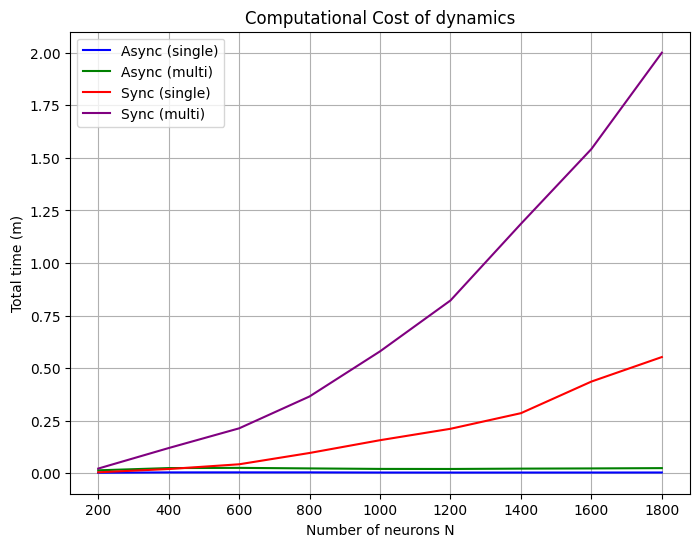

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(N_values, times_async1, '-', color = 'blue', label='Async (single)')
plt.plot(N_values, times_async2, '-', color = 'green', label='Async (multi)')
plt.plot(N_values, times_sync1, '-', color = 'red', label='Sync (single)')
plt.plot(N_values, times_sync2, '-', color = 'purple', label='Sync (multi)')
plt.xlabel('Number of neurons N')
plt.ylabel('Total time (m)')
plt.title('Computational Cost of dynamics')
plt.legend()
plt.grid(True)
plt.show()

Now, in contrast with the previous calculus, our objective is to compute the time per computation, not the total cost of the dynamics. To do it, we have to observe that if in the synchronous model, for each time_step we update each neuron, in the end of the process we end up updating N*time_step neurons.

In [ ]:
import time
import matplotlib.pyplot as plt

N_values = np.arange(200,2000,200)
P = 100
time_steps = 300
p = 10
#number of experiments to improve graphics
num_exp = 25

times_async1aux = []
times_async2aux = []
times_sync1aux = []
times_sync2aux = []

for N in N_values:
  for i in range (num_exp):
    X = generate_patterns(P,N)
    M = generate_Weight(X)
    sigma_single = initial_state(N)
    sigma_multiple = np.random.choice([1,-1],size = (N,p))

    #case asyncr1
    start = time.time()
    sigma_actual = network_dinamics_asyncr1(time_steps*N, M, sigma_single)
    times_async1aux.append(time.time()-start)

    #case asyncr2
    start = time.time()
    sigma_actual = network_dinamics_asyncr2(time_steps*N, M, sigma_multiple)
    times_async2aux.append(time.time()-start)

    #case syncr1
    start = time.time()
    sigma_actual = network_dinamics_syncr1(time_steps, M, sigma_single)
    times_sync1aux.append(time.time()-start)

    #case syncr2
    start = time.time()
    sigma_actual = network_dinamics_syncr1(time_steps, M, sigma_multiple)
    times_sync2aux.append(time.time()-start)


In [ ]:
from statistics import mean

#and now we will regroup in N_values groups of num_exp elements each array considering that we have num_exp*len(N_values) elements.

times_async1aux = np.array(times_async1aux)
times_async2aux = np.array(times_async2aux)
times_sync1aux = np.array(times_sync1aux)
times_sync2aux = np.array(times_sync2aux)

def groups(vector, num_exp):
  vector = vector.reshape(len(N_values), num_exp)
  #now we have the len(N_values)*num_exp elements in a matrix of num_exp columns and len(N_values)rows
  return vector.mean(axis = 1), vector.std(axis = 1)
  #this returns a vector of N_values elements, each of them consisting of the mean of the num_exp values for each N_value.


times_async1, std_async1 = groups(times_async1aux, num_exp)
times_async2, std_async2 = groups(times_async2aux, num_exp)
times_sync1, std_sync1 = groups(times_sync1aux, num_exp)
times_sync2, std_sync2 = groups(times_sync2aux, num_exp)

Now, we plot the computational cost per sweep and computational cost per neuron update for all 4 update rules.

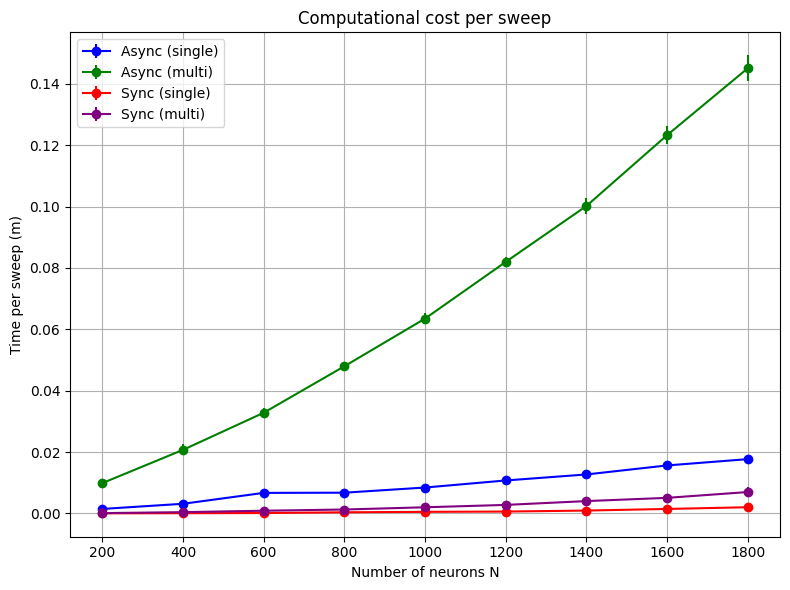

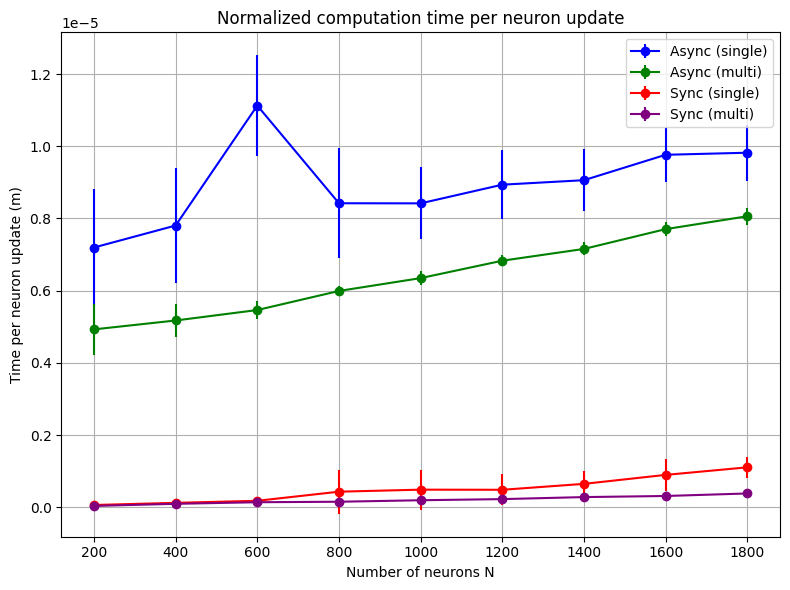

In [ ]:
# total time per sweep
plt.figure(figsize=(8,6))
plt.errorbar(N_values, times_async1/time_steps, yerr=std_async1/time_steps, fmt='-o', color='blue', label='Async (single)')
plt.errorbar(N_values, times_async2/time_steps, yerr=std_async2/time_steps, fmt='-o', color='green', label='Async (multi)')
plt.errorbar(N_values, times_sync1/time_steps,  yerr=std_sync1/time_steps,  fmt='-o', color='red', label='Sync (single)')
plt.errorbar(N_values, times_sync2/time_steps,  yerr=std_sync2/time_steps,  fmt='-o', color='purple', label='Sync (multi)')

plt.xlabel('Number of neurons N')
plt.ylabel('Time per sweep (m)')
plt.title('Computational cost per sweep')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#total time per neuron
plt.figure(figsize=(8,6))
plt.errorbar(N_values, times_async1/(time_steps*N_values), yerr=std_async1/(time_steps*N_values), fmt='-o', color='blue', label='Async (single)')
plt.errorbar(N_values, times_async2/(time_steps*N_values*p), yerr=std_async2/(time_steps*N_values*p), fmt='-o', color='green', label='Async (multi)')
plt.errorbar(N_values, times_sync1/(time_steps*N_values),    yerr=std_sync1/(time_steps*N_values),    fmt='-o', color='red', label='Sync (single)')
plt.errorbar(N_values, times_sync2/(time_steps*N_values*p),  yerr=std_sync2/(time_steps*N_values*p),  fmt='-o', color='purple', label='Sync (multi)')

plt.xlabel('Number of neurons N')
plt.ylabel('Time per neuron update (m)')
plt.title('Normalized computation time per neuron update')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In this section, we define the functions necessary to numerically measure the storage capacity of the Hopfield network.

1. measuring_recall2: This function tests the stability of a single stored pattern. It introduces noise by flipping a fraction of the bits (ratio_change), evolves the network state using the dynamics (assumed here to be synchronous via network_dinamics_syncr1), and checks if the final state overlaps sufficiently with the original pattern (overlap $\ge$ treshold).

2. measuring_capacity2: This function iterates over a range of pattern counts ($P$). For each $P$, it runs multiple experiments where it generates random patterns, constructs the weight matrix, and attempts to recall every stored pattern. It calculates the Performance (fraction of successfully recalled patterns) to determine where the memory capacity breaks down.

In [ ]:
def measuring_recall2(weight_matrix, ratio_change, time_steps, pattern_matrix, pattern_index, treshold):
  """
      Measure recall performance for a single pattern.

      Args:
          weight_matrix (np.ndarray): Weight matrix
          pattern_matrix (np.ndarray): Stored patterns
          pattern_index (int): 1-based index of pattern to test
          ratio_change (float): Fraction of bits to flip in initial state
          time_steps (int): Number of synchronous updates
          threshold (float): Overlap threshold for success

      Returns:
          tuple: (success, overlap)
  """
  changed = change_bits(ratio_change, len(weight_matrix[:,0]),pattern_matrix, pattern_index)
  actual_state = network_dinamics_syncr1(time_steps, weight_matrix, changed)
  overlap = (actual_state@pattern_matrix[:,pattern_index-1])/len(actual_state)
  return overlap >= treshold, overlap

def measuring_capacity2(P_vector,num_neurons,time_steps, treshold, ratio_change, number_experiments):
   """
    Evaluate performance of Hopfield network for different numbers of patterns.

    Args:
        P_vector (list[int]): Different numbers of patterns to test
        num_neurons (int): Number of neurons in network
        time_steps (int): Number of time steps per recall
        threshold (float): Success threshold for recall
        ratio_change (float): Fraction of bits to flip initially
        num_experiments (int): Number of experiments per pattern count

    Returns:
        list[float]: Performance for each pattern count
  """
   performances = []
   for P in P_vector:
     success_pattern_count = 0
     for experiment in range(number_experiments):
         # Generate patterns and create weight matrix
         X = generate_patterns(P, num_neurons)
         M = generate_Weight(X)

         # Test recall for each pattern
         for i in range(P):
             success_pattern= measuring_recall2(M,ratio_change, time_steps, X, i+1, treshold)[0]
             if success_pattern:
                 success_pattern_count += 1
     performance = success_pattern_count / (number_experiments*P)
     performances.append(performance)
     print(f"P={P}, α={P/N:.8f}, Performance={performance:.8f}")
   return performances

We will do the same graphic (performance vs α) for synchronous dynamics.

In [ ]:
N = 200
P_values = [5, 10, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
ratio = 0
treshold = 0.95
number_experiments = 10
# Measure capacity
performances = measuring_capacity2(P_values, N, time_steps, treshold, ratio,number_experiments)

P=5, α=0.02500000, Performance=1.00000000
P=10, α=0.05000000, Performance=1.00000000
P=20, α=0.10000000, Performance=0.99500000
P=25, α=0.12500000, Performance=0.94400000
P=30, α=0.15000000, Performance=0.86333333
P=40, α=0.20000000, Performance=0.37500000
P=50, α=0.25000000, Performance=0.11800000
P=60, α=0.30000000, Performance=0.00666667
P=70, α=0.35000000, Performance=0.00000000
P=80, α=0.40000000, Performance=0.00000000
P=90, α=0.45000000, Performance=0.00000000
P=100, α=0.50000000, Performance=0.00000000


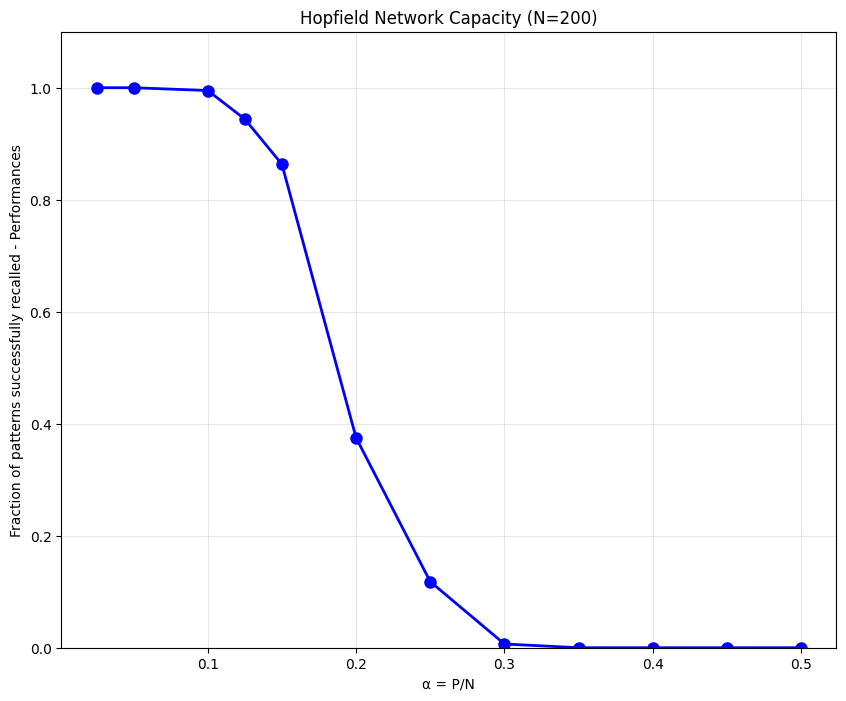

In [ ]:
import matplotlib.pyplot as plt
alphas = [P/N for P in P_values]
#alphas = [P for P in P_values]

plt.figure(figsize = (10,8))
plt.plot(alphas, performances, 'bo-', linewidth=2, markersize=8)
plt.xlabel('α = P/N')
plt.ylabel('Fraction of patterns successfully recalled - Performances')
plt.title('Hopfield Network Capacity (N=200)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.show()

Now, we will implement the asynchronous Glauber dynamics for the Hopfield model using the conditions and parametres proposed in the exercises. Note that is very similar to the asynchronous function that we already have, we only have to modify the condition of how each bit actualizes.

First, we will clarify some calculations.

In the first function ,*initial_state_overlap*, we introduce *k*, that is the number of bits that we have to flip in order to ensure that the overlap between $x^{(1)}$ and sigma is $m_{0}$. To do it, observe that as $m_{0} = \frac{1}{N}\sum_{i = 1}^{N}x_{i}^{(1)}\sigma_{i}$, and we want to determine the number of flips changed *k* to obtain an overlap $m_{0}$, $m_{0} = \frac{N-2k}{N}$. We can write the overlap like that because after flipping one bit from the original $x^{(1)}$, we change the contribution of *+1* to *-1*. So rearranging the expression that we have, we obtain $k = \frac{N(1-m_{0})}{2}$.

In the second function, *glauber*, we have to compute the probabilities $\mathbb{P}(σ = 1)$ and $\mathbb{P}(\sigma = -1)$. Observe that $\mathbb{P}(\sigma = 1) = 1 - \mathbb{P}(\sigma = -1)$. In class, we deduced that $\mathbb{P}(σ = 1) = \frac{e^{βh_{i}}}{e^{-βh_{i}} + e^{βh_{i}}}$ where $h_{i} = \sum_{j\neq i}W_{ij}\sigma_{j}$. We can transform that expression to $\mathbb{P}(\sigma = 1) = \frac{1}{1 + e^{-2βh_{i}}}$. Now, knowing that tanh(x) and sigmoid(x) are activation functions, and the relationship $ \frac{1}{1 + e^{-x}} =sigmoid(x) = \frac{1 + tanh(\frac{x}{2})}{2}$; one can derive that $\mathbb{P}(σ = 1) = \frac{1 + tanh(βh_{i})}{2}$.
We implement the tanh expression in the code due to numerically stability.



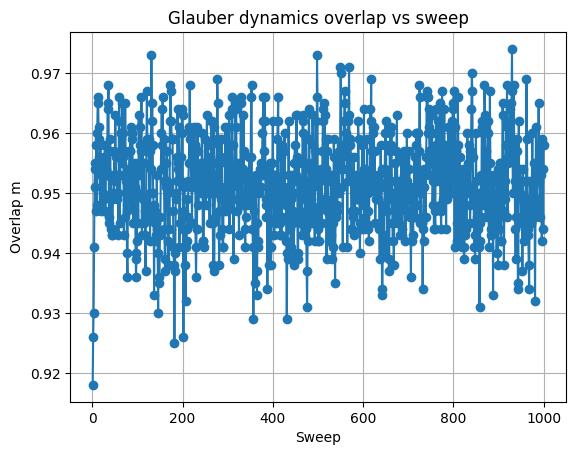

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def initial_state_overlap(x1, m0):
  """
      Return the initial state considering that the overlap between the initial state and
      x1 should be m0.

      Args:
          x1 (np.ndarray): First pattern
          m0 (int): Overlap required

      Returns:
          np.ndarray: Initial state sigma
  """
  sigma = x1.copy()
  N = len(x1)
  k = int(N*(1-m0)/2)
  if k >0:
    vec = random_vector(N,k)
    for i in range (N):
      if vec[i] == 1:
        sigma[i] = 1 if sigma[i] == -1 else -1
  return sigma


def glauber(m0, beta, N, alpha, num_sweeps):
  """
      Return the overlaps at the final of each sweep (oberve: in total we have:
      num_sweeps*N time_steps if we compare it with the normal asynchronous model).

      Args:
          m0 (int): Overlap required
          beta (float): the inverse of temperature (ie. 1/T)
          N (int): the number of neurons
          alpha (float): the ratio P/N (where P is the number of patterns)
          num_sweeps (int): the number of total sweeps

      Returns:
          overlaps(np.ndarray): The overlaps at each sweep
          sigma(np.ndarray): The final state
  """
  P = int(alpha*N) #as alpha = P/N
  X = generate_patterns(P, N)
  M = generate_Weight(X)
  x1 = X[:, 0]
  sigma = initial_state_overlap(x1, m0)
  overlaps = []
  for sweep in range(num_sweeps):
    #a sweep is like a cycle (ie. when all the neurons are actualized)
      for _ in range(N):
        #and in each sweep we have to actualize all the neurons
        #but in a random order
          i = np.random.randint(N)
          h_i = M[i, :] @ sigma
          #p_plus = 0.5*(1.0 / (1.0 + np.exp(-2*beta*h_i)))
          #we prefer the second option because numerically is better
          p_plus = 0.5 * (1 + np.tanh(beta * h_i))
          sigma[i] = 1 if np.random.rand() < p_plus else -1
          #with a certain probability it actualizes, and with a certain
          #probability not
      m = (x1 @ sigma) / N
      overlaps.append(m)
  return np.array(overlaps), sigma

overlaps, sigma_final = glauber(m0=0.9, beta=2, N=2000, alpha=0.01, num_sweeps=1000)
#when beta is low (ie. T is high) the overlaps are low, and tend to 0;
#when beta is high(ie. T is low) the overlaps tend to 1

plt.plot(np.arange(1, len(overlaps)+1), overlaps, '-o')
plt.xlabel('Sweep')
plt.ylabel('Overlap m')
plt.title('Glauber dynamics overlap vs sweep')
plt.grid(True)
plt.show()


Let us make our experimental figure.

We will set $\beta$ = 2, $m_0$ = 0.9 and the number of sweeps to 1000. We will also compute $\alpha$ in different values and we will simulate the Glauber dynamics for each $\alpha$ from a random initial condition with the given $m_0$. We will also make two graphs:

The first one will show the equilibrium m gotten at the end of the simulation for every $\alpha$.

In the other we will show the traces of m over time. In this graph, the yellow color correspond to higher values of $\alpha$, while the purple to lower values.

Simulating for alpha = 0.01
0.9541399999999998
Simulating for alpha = 0.02
0.9450800000000001
Simulating for alpha = 0.03
0.9408200000000001
Simulating for alpha = 0.04
0.6822999999999999
Simulating for alpha = 0.05
0.47074
Simulating for alpha = 0.06
0.23228
Simulating for alpha = 0.07
0.36456000000000005
Simulating for alpha = 0.08
0.16724


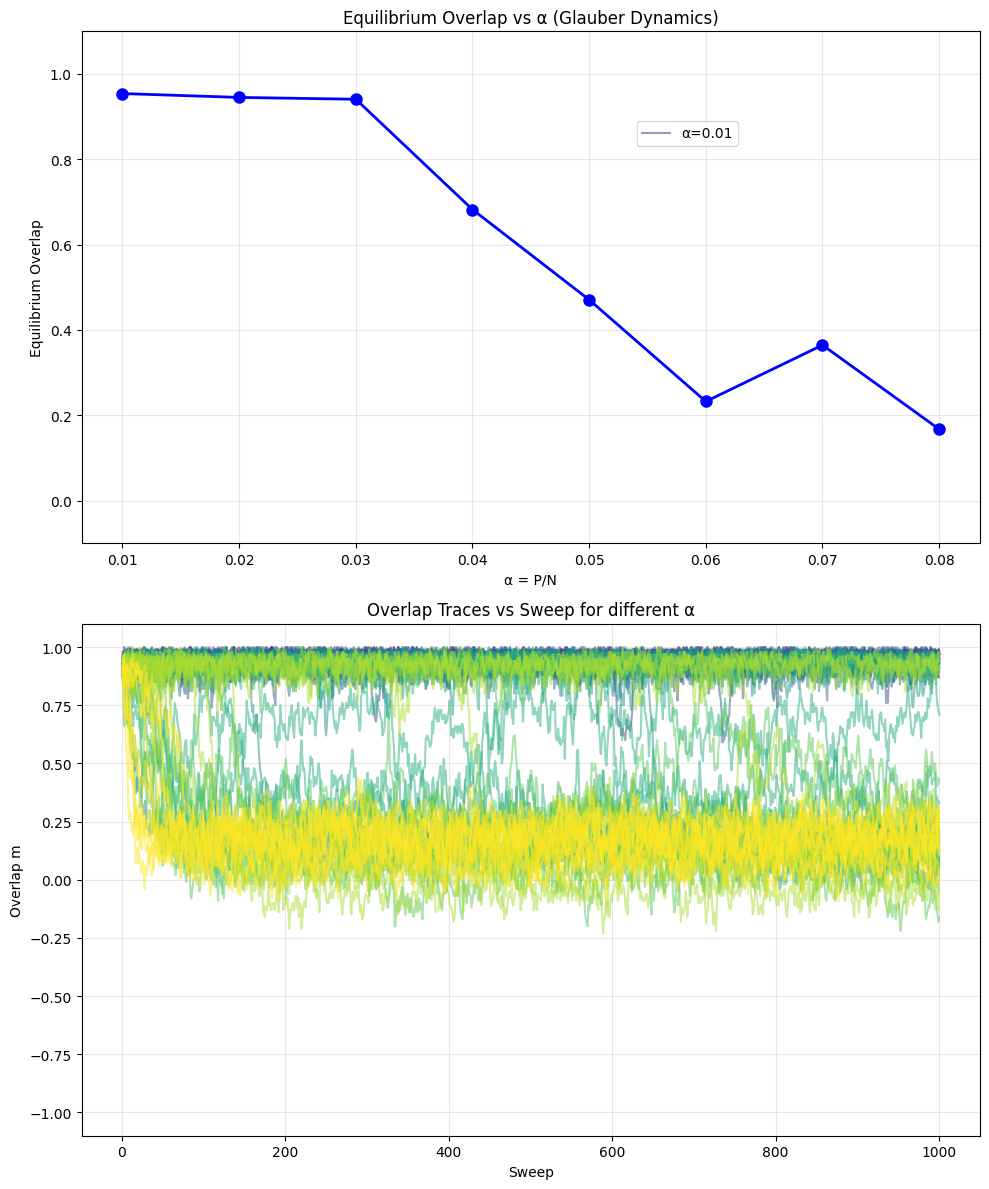

In [ ]:

# Parameters
beta = 2
m0 = 0.9
num_sweeps = 1000
N = 200  # Keep N constant as in previous cells
alpha_values = np.arange(0.01, 0.081, 0.01) # Range of alpha values
num_repetitions = 10

# Data storage
equilibrium_overlaps = []
all_overlap_traces = {}

# Simulate Glauber dynamics for each alpha and repetition
for alpha in alpha_values:
    print(f"Simulating for alpha = {alpha:.2f}")
    overlap_traces_for_alpha = []
    for rep in range(num_repetitions):
        overlaps, sigma_final = glauber(m0=m0, beta=beta, N=N, alpha=alpha, num_sweeps=num_sweeps)
        overlap_traces_for_alpha.append(overlaps)

    # Calculate equilibrium overlap for this alpha
    # Average the last 50 steps and then average over repetitions
    equilibrium_m_alpha = np.mean([np.mean(trace[-50:]) for trace in overlap_traces_for_alpha])
    print(equilibrium_m_alpha)
    equilibrium_overlaps.append(equilibrium_m_alpha)
    all_overlap_traces[alpha] = overlap_traces_for_alpha

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=False)

# Panel 1: Equilibrium overlap vs alpha
axes[0].plot(alpha_values, equilibrium_overlaps, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('α = P/N')
axes[0].set_ylabel('Equilibrium Overlap')
axes[0].set_title('Equilibrium Overlap vs α (Glauber Dynamics)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

# Panel 2: Overlap traces over time for different alphas
for i, alpha in enumerate(alpha_values):
    for trace in all_overlap_traces[alpha]:
        axes[1].plot(np.arange(1, num_sweeps + 1), trace, label=f'α={alpha:.2f}' if i==0 and trace is all_overlap_traces[alpha][0] else "", color=plt.cm.viridis(alpha/alpha_values.max()), alpha=0.5)

axes[1].set_xlabel('Sweep')
axes[1].set_ylabel('Overlap m')
axes[1].set_title('Overlap Traces vs Sweep for different α')
# Create a legend outside the plot to avoid clutter
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.75, 0.9))

axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.1, 1.1)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()



New Glauber Dynamics, allows to make faster computations by applying an optimization step.

Computational Optimization: To simulate large systems ($N=16000$) efficiently, we do not recompute the local field $h_i = \sum_j J_{ij}\sigma_j$ from scratch at every step (which would be slow, $O(N^2)$). Instead, we maintain the overlap vector $m^\mu$ and update it incrementally only when a spin flips. This reduces the complexity of calculating the field to $O(P)$.

In [ ]:
def Glauber_dynamics (m0, beta, N, alpha, num_sweeps):
  """
      Return the overlaps at the final of each sweep (oberve: in total we have:
      num_sweeps*N time_steps if we compare it with the normal asynchronous model).

      Args:
          m0 (int): Overlap required
          beta (float): the inverse of temperature (ie. 1/T)
          N (int): the number of neurons
          alpha (float): the ratio P/N (where P is the number of patterns)
          num_sweeps (int): the number of total sweeps

      Returns:
          overlaps(np.ndarray): The overlaps at each sweep
          sigma(np.ndarray): The final state
  """
  P = int(alpha*N) #as alpha = P/N
  X = generate_patterns(P, N)
  x1 = X[:, 0]
  #print(x1.shape)
  #print(X[0,:].shape)
  sigma = initial_state_overlap(x1, m0)
  overlaps = []
  m = []
  for j in range(P):
    m.append(X[:,j]@sigma *(1/N))
  m = np.array(m)
  #print(m.shape)
  for sweep in range(num_sweeps):
    #a sweep is like a cycle (ie. when all the neurons are actualized)
      for _ in range(N):
        #and in each sweep we have to actualize all the neurons
        #but in a random order
          i = np.random.randint(N)
          h_i = X[i, :]@m -alpha*sigma[i] # THIS IS WHAT HAS CHANGED
          #p_plus = 0.5*(1.0 / (1.0 + np.exp(-2*beta*h_i)))
          #we prefer the second option because numerically is better
          p_plus = 0.5 * (1 + np.tanh(beta * h_i))
          old = sigma[i] #THIS
          sigma[i] = 1 if np.random.rand() < p_plus else -1
          if (old!=sigma[i]): #AND THIS
            delta = (sigma[i]-old)*(1/N)
            m += delta*X[i,:] #AND THIS
          #with a certain probability it actualizes, and with a certain
          #probability not
      overlaps.append(m[0])
  return np.array(overlaps), sigma

Plots with new Glauber Function optimized

In [ ]:
overlaps, sigma_final = Glauber_dynamics(m0=0.90, beta=2, N=2000, alpha=0.01, num_sweeps=1000)
#when beta is low (ie. T is high) the overlaps are low, and tend to 0;
#when beta is high(ie. T is low) the overlaps tend to 1

plt.plot(np.arange(1, len(overlaps)+1), overlaps, '-o')
plt.xlabel('Sweep')
plt.ylabel('Overlap m')
plt.title('Glauber dynamics overlap vs sweep')
plt.grid(True)
plt.show()

In [ ]:
# Parameters
beta = 2
m0 = 0.9
num_sweeps = 1000
N = 4000  # Keep N constant as in previous cells
alpha_values = np.arange(0.01, 0.081, 0.01) # Range of alpha values
num_repetitions = 10

# Data storage
equilibrium_overlaps = []
all_overlap_traces = {}

# Simulate Glauber dynamics for each alpha and repetition
for alpha in alpha_values:
    print(f"Simulating for alpha = {alpha:.2f}")
    overlap_traces_for_alpha = []
    for rep in range(num_repetitions):
        overlaps, sigma_final = Glauber_dynamics(m0=m0, beta=beta, N=N, alpha=alpha, num_sweeps=num_sweeps)
        overlap_traces_for_alpha.append(overlaps)

    # Calculate equilibrium overlap for this alpha
    # Average the last 50 steps and then average over repetitions
    equilibrium_m_alpha = np.mean([np.mean(trace[-50:]) for trace in overlap_traces_for_alpha])
    print(equilibrium_m_alpha)
    equilibrium_overlaps.append(equilibrium_m_alpha)
    all_overlap_traces[alpha] = overlap_traces_for_alpha


Simulating for alpha = 0.01
0.9517899999999944
Simulating for alpha = 0.02
0.9451409999999951
Simulating for alpha = 0.03
0.9366569999999961
Simulating for alpha = 0.04
0.9206539999999975
Simulating for alpha = 0.05
0.9046559999999996
Simulating for alpha = 0.06
0.2396520000000371
Simulating for alpha = 0.07
0.06829100000004369
Simulating for alpha = 0.08
0.04593500000004368


Plots obtained from optimizing the Glauber function. We have selected β = 2, m0 = 0.9, n_sweeps = 1000, and 10 repetitions for each setting.

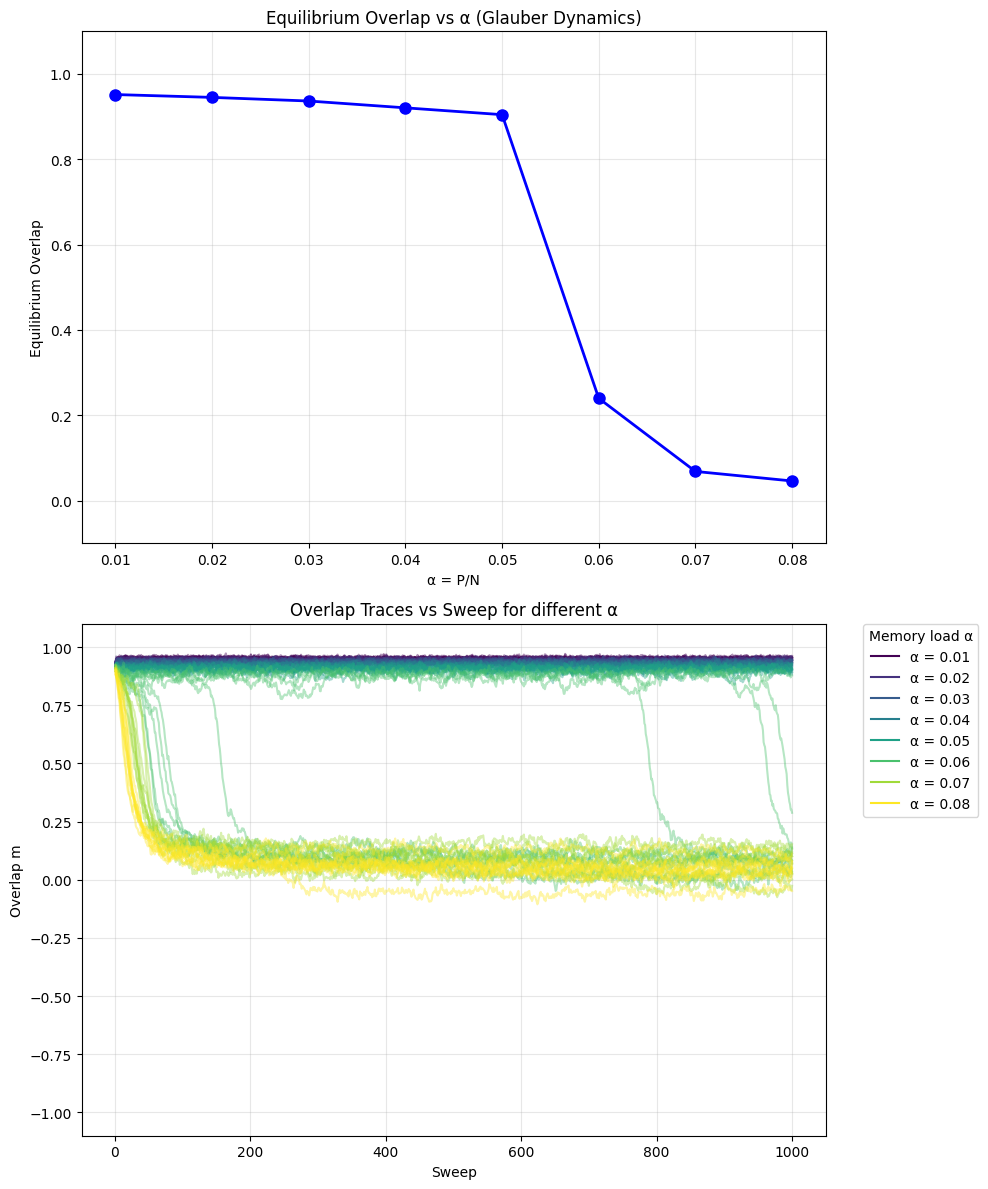

In [ ]:
# Plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=False)

# --- Panel 1: Equilibrium overlap vs alpha ---
axes[0].plot(alpha_values, equilibrium_overlaps, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('α = P/N')
axes[0].set_ylabel('Equilibrium Overlap')
axes[0].set_title('Equilibrium Overlap vs α (Glauber Dynamics)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

# --- Panel 2: Overlap traces over time for different α ---
colors = plt.cm.viridis(np.linspace(0, 1, len(alpha_values)))  # consistent color map

for i, alpha in enumerate(alpha_values):
    color = colors[i]
    for trace in all_overlap_traces[alpha]:
        axes[1].plot(
            np.arange(1, num_sweeps + 1),
            trace,
            color=color,
            alpha=0.4
        )
    # Add one representative line per α to legend
    axes[1].plot([], [], color=color, label=f'α = {alpha:.2f}')

axes[1].set_xlabel('Sweep')
axes[1].set_ylabel('Overlap m')
axes[1].set_title('Overlap Traces vs Sweep for different α')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.1, 1.1)

# Legend — placed nicely outside
axes[1].legend(title="Memory load α", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
fig.savefig("glauber_panels.png", dpi=300, bbox_inches='tight')
plt.show()